In [1]:
import numpy as np
import pymc3 as pm
import arviz as az
import matplotlib.pyplot as plt

from dataclasses import dataclass
from colorsys import hls_to_rgb, rgb_to_hls, rgb_to_hsv

np.random.seed(42)

# Bayesian Optimization with Gaussian Processes

In [2]:
@dataclass
class HLS:
    """https://www.w3schools.com/colors/colors_hsl.asp"""
    hue: float  # 0-1
    lightness: float  # 0-1
    saturation: float = 0.6 # 0-1


    def dist(self, hls):
        # https://en.wikipedia.org/wiki/Color_difference
        # https://docs.python.org/3/library/colorsys.html
        r1, g1, b1 = hls_to_rgb(self.hue, self.lightness, self.saturation)
        r2, g2, b2 = hls_to_rgb(hls.hue, hls.lightness, hls.saturation)

        dr, dg, db = r1 - r2, g1 - g2, b1 - b2
        distance = np.sqrt(dr * dr + dg * dg + db * db)
        return distance


class Env:
    hue_len = 50
    light_len = 50
    hue_domain = np.linspace(0, 1, hue_len)
    light_domain = np.linspace(0, 1, light_len)
    X, Y = np.meshgrid(hue_domain, light_domain)
    _x = X.flatten()
    _y = Y.flatten()
    xy = np.vstack((_x, _y)).T


class User:
    def __init__(self, preference=HLS(0.5, 0.6)):
        self.preference = preference

    def response(self, hls: HLS):
        dist = self.preference.dist(hls)
        reward = 5 * np.exp(-dist)
        return Response(hls, reward)


@dataclass()
class Response:
    hls: HLS
    reward: float


class StateRepository:
    def __init__(self, responses=[]):
        self.responses = responses

    @property
    def X(self):
        hlss = [res.hls for res in self.responses]
        X = np.array([(hls.hue, hls.saturation) for hls in hlss])
        return X.T

    @property
    def y(self):
        rewards = [res.reward for res in self.responses]
        y = np.array(rewards)
        return y

    def append(self, response):
        self.responses.append(response)


class GPThompsonAgent:
    def __init__(self):
        self.model = None
        self.trace = None
        self.gp = None

    def get_param(self, X, y):
        self.model = pm.Model()
        with self.model:
            length = pm.Gamma('length', 2, 2)
            cov = pm.gp.cov.ExpQuad(input_dim=2, ls=length) + pm.gp.cov.WhiteNoise(1E-5)
            self.gp = pm.gp.Marginal(cov_func=cov)
            eps = pm.HalfNormal('eps', 20)
            y_pred = self.gp.marginal_likelihood('y_pred', X=X.T, y=y, noise=eps)
            self.trace = pm.sample(1000, chains=1)

        with self.model:
            f_pred = self.gp.conditional('f_pred', Env.xy)
            pred_samples = pm.sample_posterior_predictive(self.trace, var_names=["f_pred"], samples=100)



        # Averaging the functions makes the algorithm more exploitative. But it converges faster.
        Z_ = np.mean(pred_samples['f_pred'], axis=0).reshape((Env.hue_len, Env.light_len))
        #Z_ = pred_samples['f_pred'][0].reshape((Env.hue_len, Env.light_len))


        ind = np.unravel_index(np.argmax(Z_, axis=None), Z_.shape)
        hue = Env.hue_domain[ind[0]]
        light = Env.light_domain[ind[1]]
        return HLS(hue, light)

In [9]:
env = Env()
user = User()
agent = GPThompsonAgent()

In [10]:
res1 = user.response(HLS(0., 0.3))
res2 = user.response(HLS(0.5, 0.3))
res3 = user.response(HLS(0., 0.7))
res4 = user.response(HLS(0.5, 0.7))

repo = StateRepository([res1, res2, res3, res4])

In [11]:
for res in [res1, res2, res3, res4]:
    rgb = hls_to_rgb(res.hls.hue, res.hls.lightness, res.hls.saturation)
    print(res.hls)
    print(rgb)
    print(user.preference.dist(res.hls))
    print()

HLS(hue=0.0, lightness=0.3, saturation=0.6)
(0.48, 0.12, 0.12)
1.0252804494381036

HLS(hue=0.5, lightness=0.3, saturation=0.6)
(0.12, 0.47999999999999987, 0.48)
0.5628498911788116

HLS(hue=0.0, lightness=0.7, saturation=0.6)
(0.8799999999999999, 0.52, 0.52)
0.6893475175845633

HLS(hue=0.5, lightness=0.7, saturation=0.6)
(0.52, 0.8799999999999998, 0.8799999999999999)
0.16970562748477142



In [17]:
# Bayes opt
N = 5
for i in range(N):
    hls = agent.get_param(repo.X, repo.y)
    response = user.response(hls)
    repo.append(response)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_26486/2628939443.py:81: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  self.trace = pm.sample(1000, chains=1)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 2 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 2 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 2 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 2 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 2 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


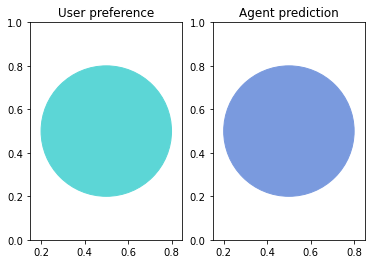

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2)

color_user = hls_to_rgb(user.preference.hue, user.preference.lightness, user.preference.saturation)
circle_user = plt.Circle((0.5, 0.5), 0.3, color=color_user)
ax1.add_patch(circle_user)
ax1.set_aspect("equal", adjustable="datalim")
ax1.set_title("User preference")

color_pred = hls_to_rgb(hls.hue, hls.lightness, hls.saturation)
circle_pred = plt.Circle((0.5, 0.5), 0.3, color=color_pred)
ax2.add_patch(circle_pred)
ax2.set_aspect("equal", adjustable="datalim")
ax2.set_title("Agent prediction")

plt.show()

In [16]:
len(repo.responses)

9

In [19]:
with agent.model:
    _f = agent.gp.conditional('_f', Env.xy)
    pred_samples = pm.sample_posterior_predictive(agent.trace, var_names=["_f"], samples=10)
    f_mean = np.mean(pred_samples['_f'], axis=0)
    Z_ = f_mean.reshape((Env.hue_len, Env.light_len))


<Figure size 432x288 with 0 Axes>

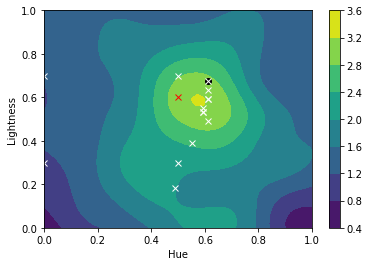

In [20]:

fig = plt.figure()
fig, ax = plt.subplots(1, 1)

cp = ax.contourf(Env.hue_domain, Env.light_domain, Z_.T)

ax.plot(user.preference.hue, user.preference.saturation, 'rx')
ax.plot(hls.hue, hls.lightness, 'ko')

res_hues = [res.hls.hue for res in repo.responses]
res_lights = [res.hls.lightness for res in repo.responses]
ax.plot(res_hues, res_lights, 'xw')

fig.colorbar(cp)
ax.set_xlabel('Hue')
ax.set_ylabel('Lightness')
plt.show()